 # 동계 올림픽 개최국 GDP 추이 분석
 이 노트북은 동계 올림픽 개최 전후 5년 동안의 개최국 GDP 변화를 시각화합니다.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import koreanize_matplotlib
from matplotlib.ticker import FormatStrFormatter

# ──────────────────────────────────────────────
# 상수 & 설정
# ──────────────────────────────────────────────
WINDOW = 5   # 올림픽 전후 몇 년을 볼 것인지

OLYMPIC_TO_GDP_NAME: dict[str, str] = {
    'Republic of Korea': 'Korea, Rep.',
    'Russian Federation': 'Russian Federation',
    'Canada':             'Canada',
    'Italy':              'Italy',
    'Japan':              'Japan',
    'Norway':             'Norway',
    'France':             'France',
    'United States':      'United States',
    'China':              'China',
}

KOREAN_NAME: dict[str, str] = {
    'Republic of Korea': '한국',
    'Russian Federation': '러시아',
    'Canada':             '캐나다',
    'Italy':              '이탈리아',
    'Japan':              '일본',
    'Norway':             '노르웨이',
    'France':             '프랑스',
    'United States':      '미국',
    'China':              '중국',
}

 ## 데이터 로드 및 전처리

In [2]:
# ──────────────────────────────────────────────
# 데이터 로드
# ──────────────────────────────────────────────
olympic_df = pd.read_csv('./data/olympic_games.csv')
gdp_raw_df = pd.read_csv('./data/gdp.csv', skiprows=4)

# ──────────────────────────────────────────────
# 동계 올림픽 개최국 필터링
# ──────────────────────────────────────────────
def get_host_winter_df(olympic_df: pd.DataFrame) -> pd.DataFrame:
    """개최국 행만 추출 → 동계 올림픽만 필터링 → 누락 연도 보완"""
    host_df = (
        olympic_df[olympic_df['host_country'] == olympic_df['country']]
        .sort_values('year', ascending=False)
    )

    target_years = [1988, 1992, 1994, 1998, 2002, 2006, 2010, 2014, 2018, 2022]
    winter_df = (
        host_df[host_df['games_type'] == 'Winter']
        .head(11)
        .pipe(lambda df: df[df['year'].isin(target_years)])
    )

    # 데이터가 없는 연도 수동 보완
    missing_rows = pd.DataFrame({
        'year':         [2002,           2022],
        'games_type':   ['Winter',       'Winter'],
        'host_country': ['United States', 'China'],
        'country':      ['United States', 'China'],
        'gold':         [np.nan,         np.nan],
        'silver':       [np.nan,         np.nan],
        'bronze':       [np.nan,         np.nan],
    })

    return pd.concat([winter_df, missing_rows], ignore_index=True)


winter_df = get_host_winter_df(olympic_df)

# ──────────────────────────────────────────────
# GDP 데이터: 필요한 국가만 필터링
# ──────────────────────────────────────────────
gdp_df = gdp_raw_df[
    gdp_raw_df['Country Name'].str.strip().isin(OLYMPIC_TO_GDP_NAME.values())
].copy()

 ## GDP 윈도우 데이터 생성 및 성장률 계산

In [3]:
# ──────────────────────────────────────────────
# 국가 × 올림픽 연도별 GDP 시계열 조합
# ──────────────────────────────────────────────
def build_gdp_window(
    gdp_df: pd.DataFrame,
    winter_df: pd.DataFrame,
    name_map: dict[str, str],
    korean_name: dict[str, str],
    window: int = 5,
) -> pd.DataFrame:
    """올림픽 개최 연도 기준 ±window 년의 GDP 데이터를 하나의 DataFrame으로 조합"""
    records = []

    for olympic_name, gdp_name in name_map.items():
        host_years = winter_df.loc[winter_df['host_country'] == olympic_name, 'year']
        country_gdp = gdp_df[gdp_df['Country Name'].str.strip() == gdp_name]

        if country_gdp.empty:
            continue

        for base_year in host_years:
            start, end = base_year - window, min(base_year + window, 2024)
            year_cols = [str(y) for y in range(start, end + 1)]

            gdp_slice = (
                country_gdp[year_cols]
                .iloc[[0]]
                .T
                .reset_index()
            )
            gdp_slice.columns = ['Year', 'GDP']
            gdp_slice['Year']          = gdp_slice['Year'].astype(int)
            gdp_slice['Country']       = gdp_name
            gdp_slice['Base_Year']     = base_year
            gdp_slice['Relative_Year'] = range(-window, len(gdp_slice) - window)
            gdp_slice['Display_Name'] = f"{korean_name[olympic_name]} ({base_year})"

            records.append(gdp_slice)

    return pd.concat(records, ignore_index=True)


final_gdp_df = build_gdp_window(gdp_df, winter_df, OLYMPIC_TO_GDP_NAME, KOREAN_NAME, WINDOW)

# ──────────────────────────────────────────────
# 성장률 계산 (개최 연도 GDP 대비)
# ──────────────────────────────────────────────
def add_growth_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values(['Display_Name', 'Relative_Year']).copy()

    host_year_gdp = (
        df[df['Relative_Year'] == 0]
        .set_index('Display_Name')['GDP']
    )
    df['Base_GDP'] = df['Display_Name'].map(host_year_gdp)

    # Growth와 Growth_Rel_To_Host는 동일한 공식 → 한 번만 계산
    df['Growth'] = (df['GDP'] / df['Base_GDP'] - 1) * 100
    df['Growth_Rel_To_Host'] = df['Growth']

    return df


final_gdp_df = add_growth_columns(final_gdp_df)

 ## 데이터 시각화

C:\Users\KDS24\AppData\Local\Temp\ipykernel_18384\4177639363.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


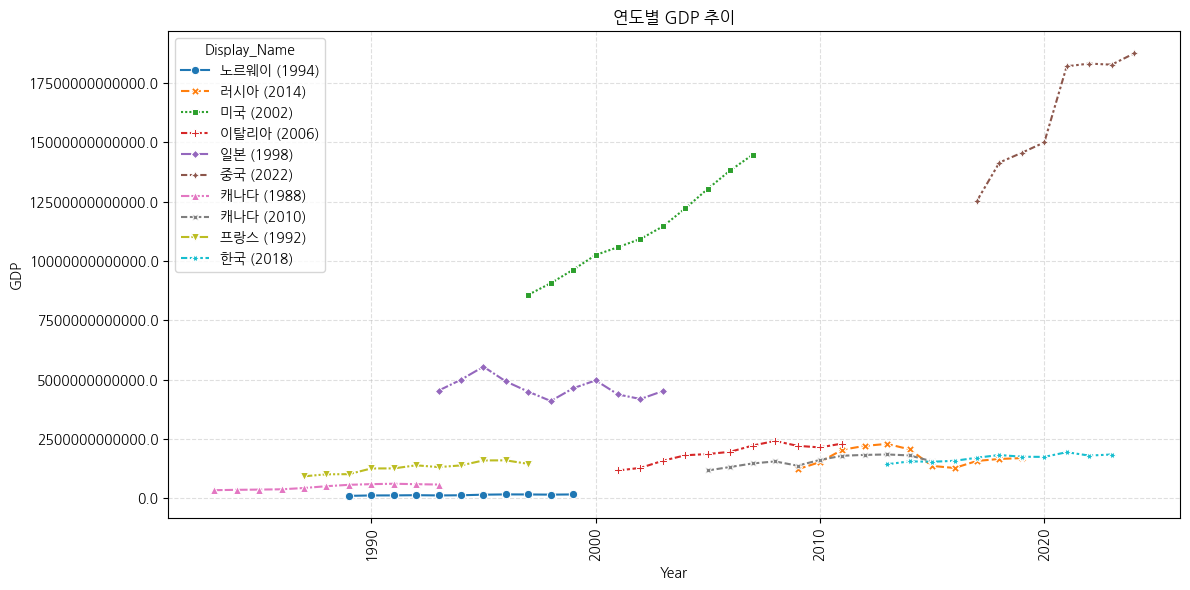

In [4]:
# ──────────────────────────────────────────────
# 시각화 공통 설정
# ──────────────────────────────────────────────
GRID_STYLE = dict(linestyle='--', alpha=0.4)

# ── 그래프 1: 연도별 절대 GDP ──────────────────
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=final_gdp_df, x='Year', y='GDP',
             hue='Display_Name', style='Display_Name', markers=True, ax=ax)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.grid(True, **GRID_STYLE)
ax.set_title("연도별 GDP 추이")
plt.tight_layout()
plt.show()

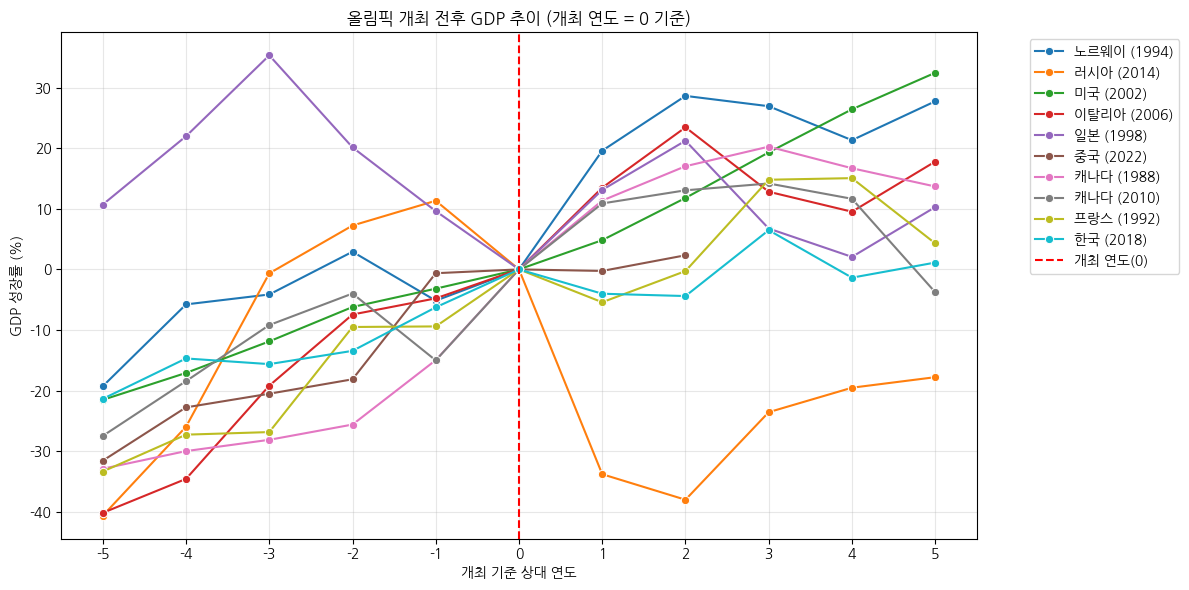

In [5]:
# ── 그래프 2: 상대 연도 기준 성장률 선 그래프 ────
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=final_gdp_df, x='Relative_Year', y='Growth',
             hue='Display_Name', marker='o', ax=ax)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='개최 연도(0)')
ax.set_xticks(range(-WINDOW, WINDOW + 1))
ax.set_title("올림픽 개최 전후 GDP 추이 (개최 연도 = 0 기준)")
ax.set_xlabel("개최 기준 상대 연도")
ax.set_ylabel("GDP 성장률 (%)")
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

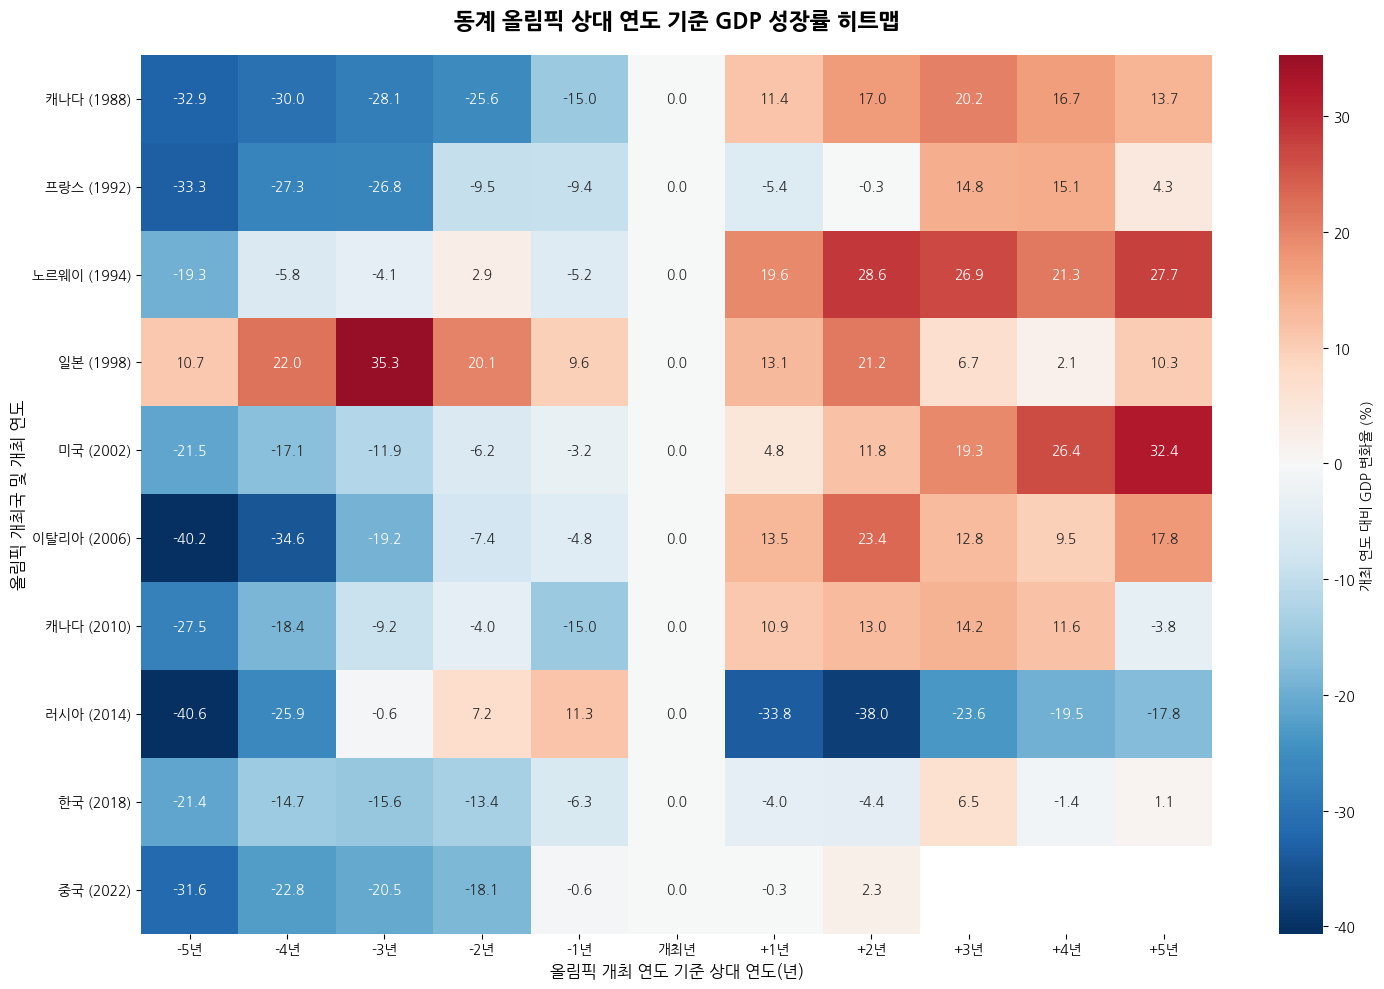

In [6]:
# ── 그래프 3: 히트맵 ──────────────────────────
sorted_countries = (
    final_gdp_df.sort_values('Base_Year')['Display_Name'].unique()
)
heatmap_data = (
    final_gdp_df
    .pivot(index='Display_Name', columns='Relative_Year', values='Growth_Rel_To_Host')
    .reindex(sorted_countries)
)

fig, ax = plt.subplots(figsize=(15, 10))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.1f', cmap='RdBu_r', center=0,
    cbar_kws={'label': '개최 연도 대비 GDP 변화율 (%)'},
    ax=ax,
)
ax.set_xlabel("올림픽 개최 연도 기준 상대 연도(년)", fontsize=12)
ax.set_ylabel("올림픽 개최국 및 개최 연도", fontsize=12)
ax.set_title("동계 올림픽 상대 연도 기준 GDP 성장률 히트맵",
             fontsize=16, pad=20, fontweight='bold')
ax.set_xticklabels([
    f"{int(float(t.get_text())):+d}년" if t.get_text() != '0' else "개최년"
    for t in ax.get_xticklabels()
])
plt.tight_layout()
plt.show()